# PINN vs GNN: Comparative Analysis

Aplicación al Problema de Poisson. 
En este contexto, la GNN aprende que la variable $u$ en un punto debe satisfacer la relación de vecindad impuesta por el operador Laplaciano $\nabla^2 u = f$. El EdgeProcessor aprende de forma implícita las derivadas espaciales, mientras que el NodeProcessor ajusta el valor de $u$ para minimizar el residuo de la ecuación en toda la malla.


## Recap
- **PINN** learned the physics by looking at the interior PDE residuals. It is mesh-free but requires careful sampling.
- **GNN** learned the behavior of the solution by observing the FEM ground truth. It is extremely fast at inference and understands the domain topology.

# Métodos de Cálculo del Residuo PDE en PiGNN
En la arquitectura PiGNN (Physics-Informed Graph Neural Network), la red debe aprender a respetar la física subyacente (por ejemplo, la ecuación de Poisson $\nabla^2 u = f$). Dependiendo de cómo se calculen las derivadas espaciales y de qué variables prediga la red de forma directa, existen cuatro formulaciones principales para construir la función de pérdida de la física ($Loss_{pde}$).A continuación se definen los cuatro enfoques implementados.

## Laplaciano desde $u$ con Diferencias Finitas Generalizadas (GFD)

*Concepto*: 
La red neuronal predice únicamente el campo escalar $u$. El operador Laplaciano se aproxima de forma puramente discreta y geométrica utilizando Diferencias Finitas Generalizadas sobre la topología del grafo.

*Peculiaridad*: 
Este método respeta estrictamente la malla o grafo proporcionado. Calcula las derivadas basándose en la diferencia del valor de $u$ entre nodos vecinos ponderada por la distancia y disposición espacial (las aristas del grafo). Es altamente estable pero depende de la calidad y resolución de la malla.

*Formulación*:
Dado que la red predice $u_{pred}$, el residuo en cada nodo $i$ se define como:

$$Res_{pde, i} = \Delta_{GFD} u_{pred, i} - f_i$$

Donde $\Delta_{GFD}$ es el operador discreto agregado sobre el vecindario $\mathcal{N}(i)$:

$$\Delta_{GFD} u_i \approx \sum_{j \in \mathcal{N}(i)} W_{ij} (u_j - u_i)$$

(Los pesos $W_{ij}$ se precalculan geométricamente en función de las coordenadas).

La pérdida total es:

$$Loss_{pde} = \frac{1}{N_{int}} \sum_{i \in \text{int}} \left( \Delta_{GFD} u_{pred, i} - f_i \right)^2$$


## Forma Mixta: $\text{div}(\mathbf{q})$ y $\text{grad}(u)$ predichos, con GFD

*Concepto*: 
La red neuronal aumenta su expresividad y predice dos entidades simultáneamente: el campo escalar $u$ en los nodos y el vector flujo $\mathbf{q}$ (que puede estar en los nodos o en las aristas). La ecuación de segundo orden se descompone en un sistema de primer orden acoplado. Las derivadas se calculan usando GFD.

*Peculiaridad*: 
Al reducir el problema a derivadas de primer orden, es mucho más amigable para la agregación de la GNN. La función de pérdida tiene que forzar dos cosas: que la divergencia del flujo cumpla la conservación (PDE) y que el flujo coincida con el gradiente negativo de $u$ (Ley de Fick/Fourier).

*Formulación*:
Sistema físico real: $\nabla \cdot \mathbf{q} = f$ y $\mathbf{q} = - \nabla u$.
Se calculan dos residuos discretos para cada nodo $i$:
1. Residuo de Conservación: $PDE_i = \text{div}_{GFD}(\mathbf{q}_{pred, i}) - f_i$
2. Residuo Constitutivo (Fick): $Fick_i = \mathbf{q}_{pred, i} + \text{grad}_{GFD}(u_{pred, i})$

La pérdida suma ambos términos (generalmente balanceados por un factor $\lambda_{Fick}$):
$$Loss_{pde} = \frac{1}{N_{int}} \sum_{i \in \text{int}} \left( PDE_i \right)^2 + \lambda_{Fick} \frac{1}{N} \sum_{i} \left( Fick_i \right)^2$$

# Laplaciano con GFD

Seed set to 42


¿Cuda disponible?: True
¿Versión de CUDA de PyTorch?: 13.0
¿Dispositivos detectados?: 1
Nombre de la GPU: NVIDIA GeForce RTX 5090
Entorno configurado para hardware: cuda
Using custom physics: <config.physics.PoissonGeneral object at 0x76f6f1ebc5e0>
Using custom physics: <config.physics.PoissonGeneral object at 0x76f6f1fc7b80>
Using custom physics: <config.physics.PoissonGeneral object at 0x76f6ee7e0be0>
Using custom physics: <config.physics.PoissonGeneral object at 0x76f6f1ebc5e0>
Using custom physics: <config.physics.PoissonGeneral object at 0x76f6f1fc7a90>


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/purdeitx/miniconda3/envs/PinnGnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PhysicsMessagePassing │ 18.6 K │ train │     0 │
│ 1 │ loss_fn │ MSELoss               │      0 │ train │     0 │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 18.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 18.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/purdeitx/miniconda3/envs/PinnGnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_conne
ctor.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.

/home/purdeitx/miniconda3/envs/PinnGnn/lib/python3.10/site-packages/pytorch_lightning/utilities/data.py:79: Trying 
to infer the `batch_size` from an ambiguous collection. The batch size we found is 441. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/purdeitx/miniconda3/envs/PinnGnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_conne
ctor.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.

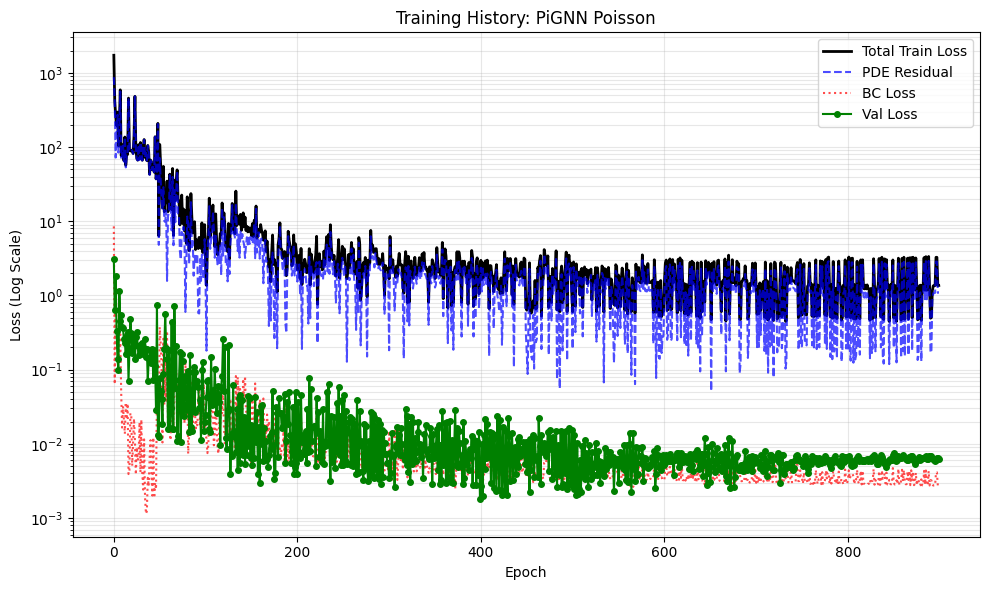

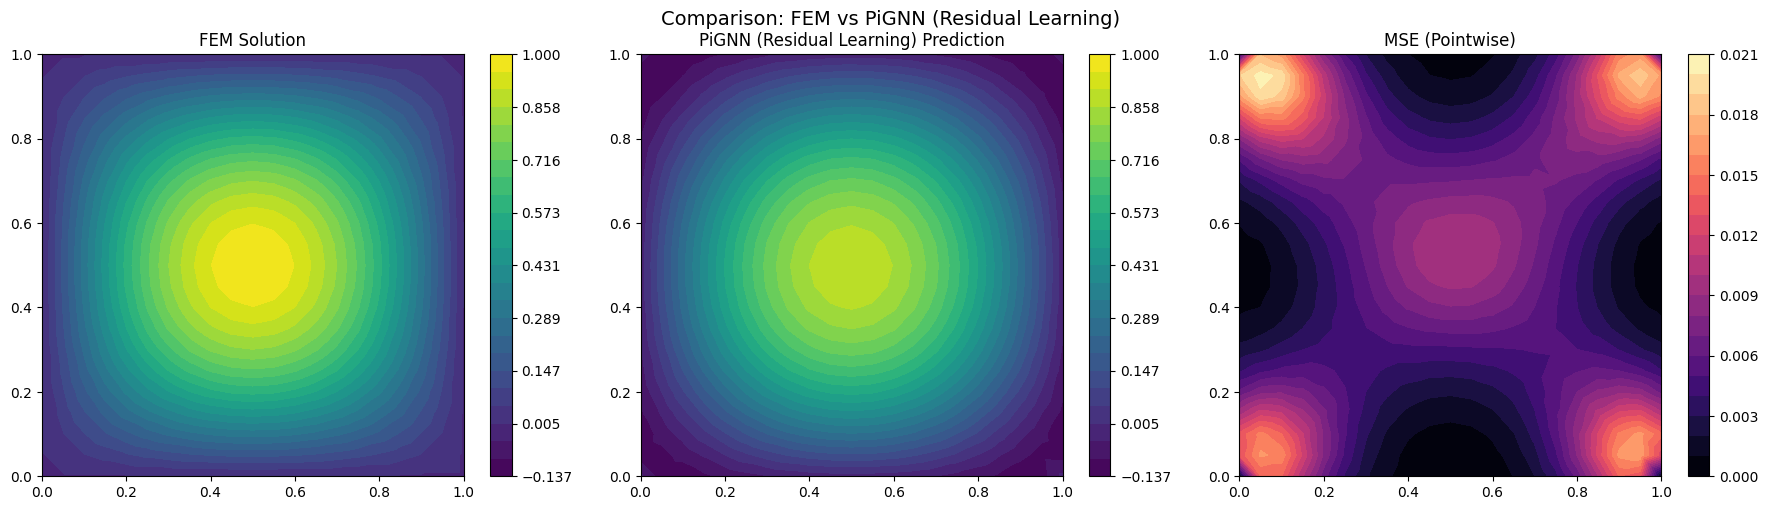

Correlación GT vs GNN: -0.5383
⚠️  Signo invertido detectado — corrigiendo


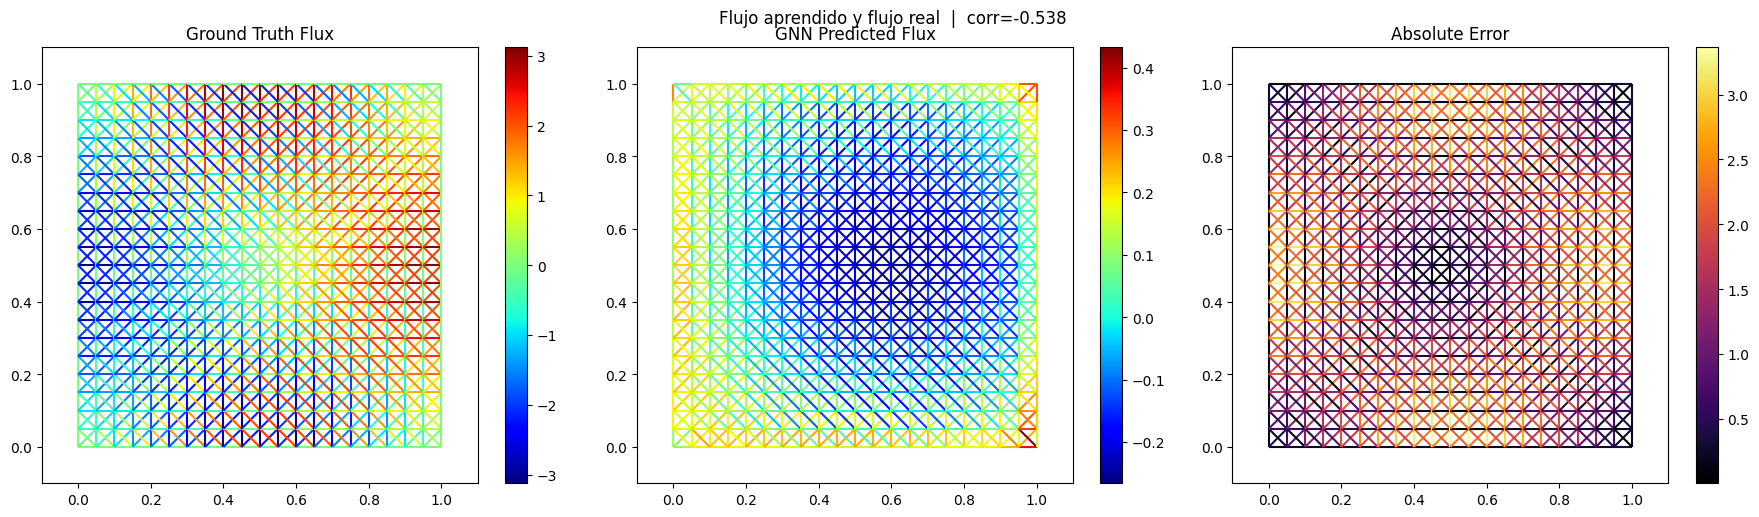

Antisimetría  — mean|flux_ij + flux_ji|: 0.1987
              — max|flux_ij + flux_ji|:  0.5004
Correlación flux_ij vs -flux_ji:  -0.3507  (1.0 = perfectamente antisimétrico)
Correlación GT vs flux_ij:        -0.5383
Correlación GT vs -flux_ji:       -0.5402


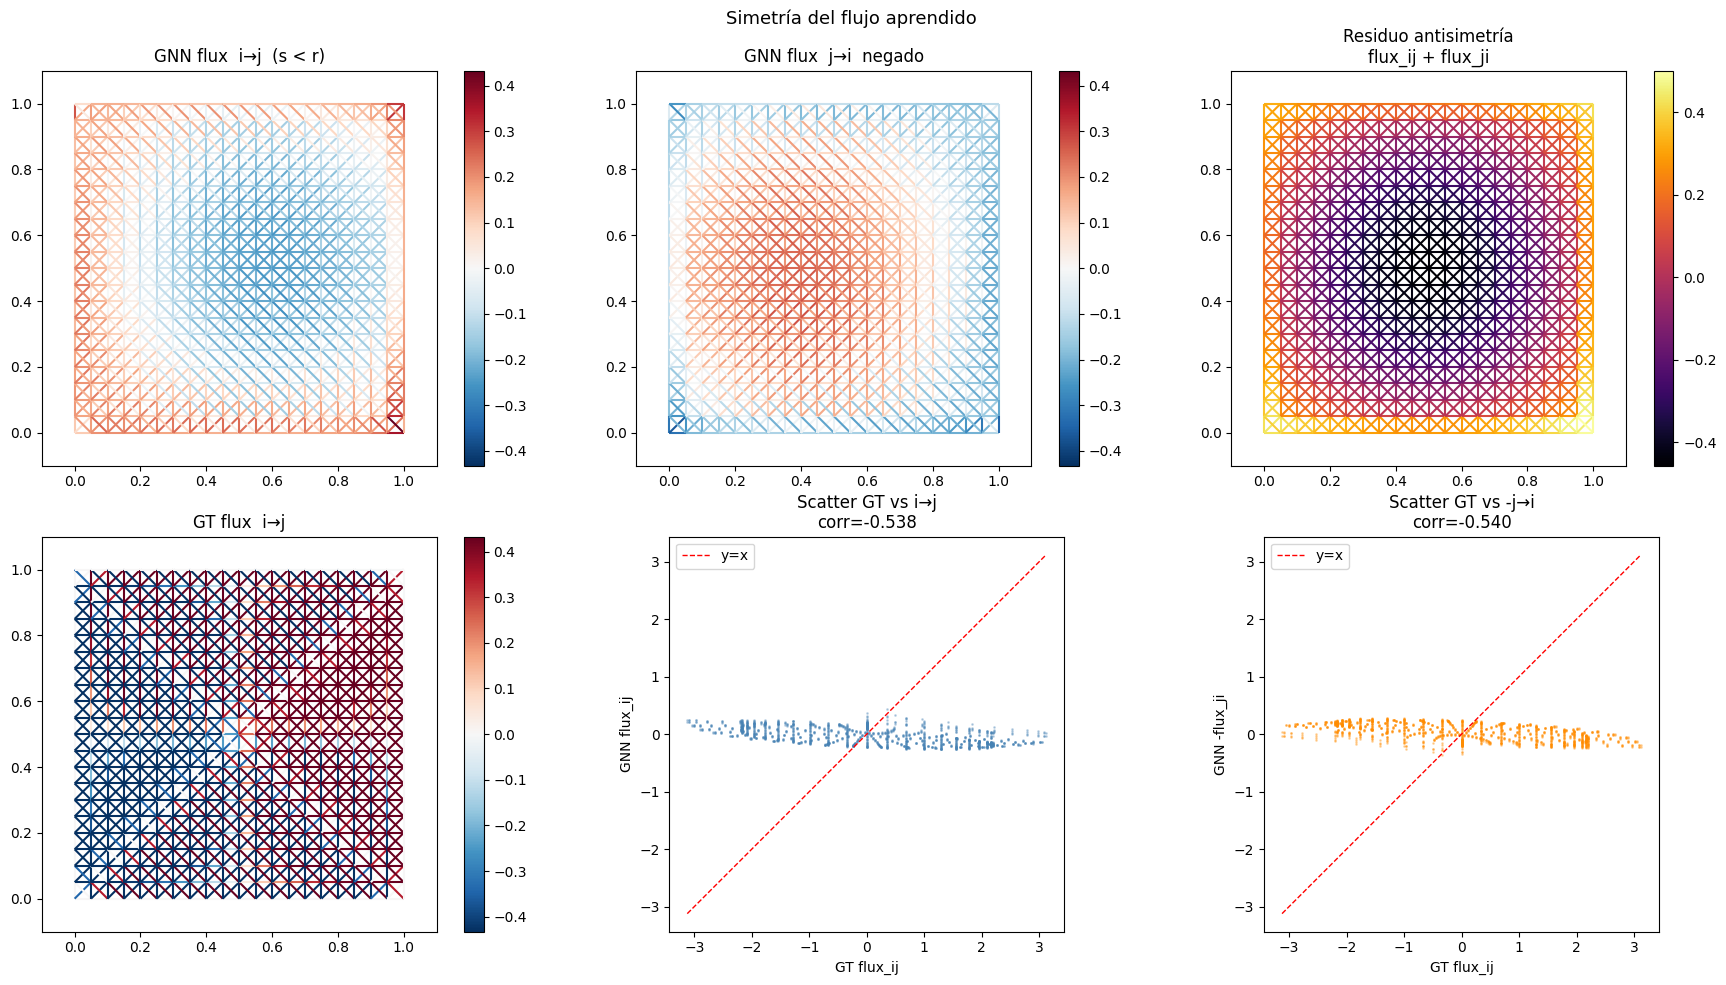

Correlación GT vs GNN: 0.9906


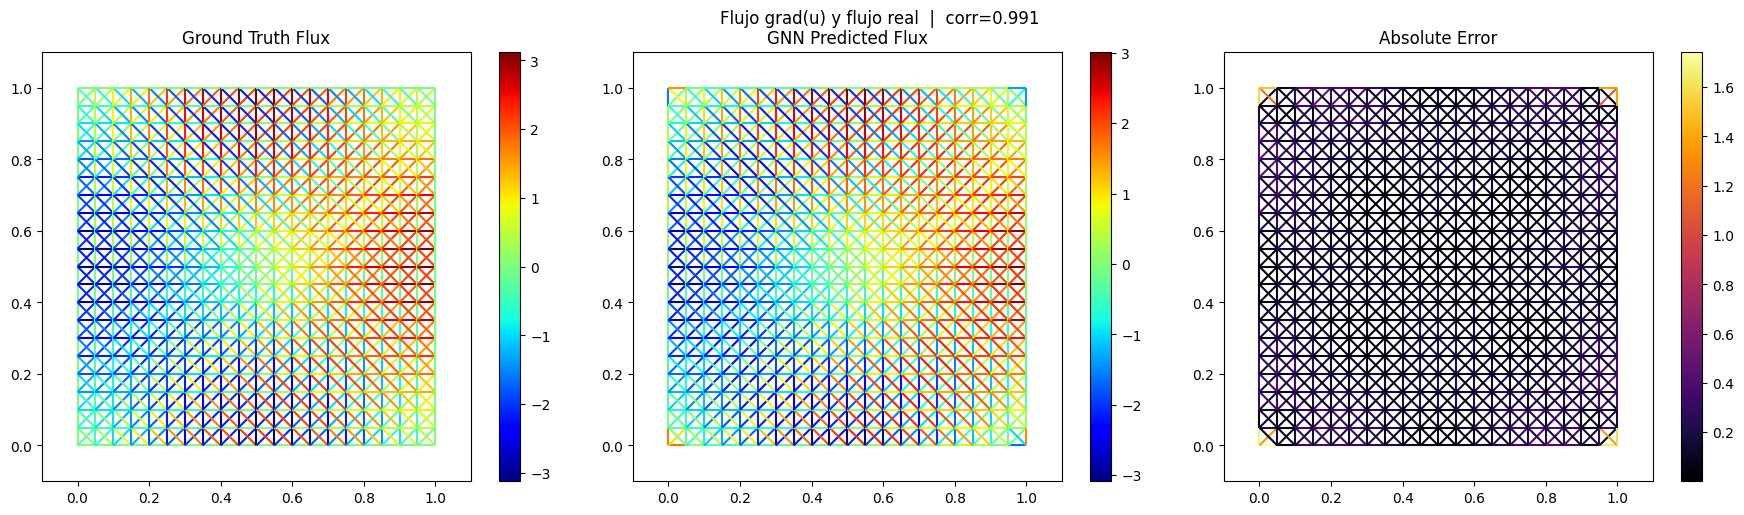

In [ ]:
# ============================================================
# Pinn Graph model
# ============================================================
import sys, os, warnings
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from torch_geometric.loader import DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

pl.seed_everything(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"¿Cuda disponible?: {torch.cuda.is_available()}")
print(f"¿Versión de CUDA de PyTorch?: {torch.version.cuda}")
print(f"¿Dispositivos detectados?: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    torch.cuda.set_device(0)
    torch.zeros(1).cuda()
    print(f"Nombre de la GPU: {torch.cuda.get_device_name(0)}")
    # torch.set_float32_matmul_precision('medium') 

print(f"Entorno configurado para hardware: {device}")


warnings.filterwarnings("ignore", ".*isinstance\(treespec, LeafSpec\).*")
warnings.filterwarnings("ignore", ".*install \"ipywidgets\" for Jupyter support.*")
torch.set_float32_matmul_precision('medium')

# Modulos locales (Asumiendo la estructura de tu proyecto)
from FEM.fem_solver import get_problem
from PiGnn.pignn_module import PhysicsMessagePassing, PhysicsSystem 
from config.physics import PoissonGeneral
from config.pignn_config import PIGNN_CONFIG
from utils.pignn_utils import FEM_to_PiGnnData 
from utils.train_utils import GradientMonitor, LossPlotterCallback, WarmupEarlyStopping
from utils.geometry import geometry_factory
from utils.plotting import plot_comparison_with_fem, plot_error_analysis, plot_flux_comparison, plot_flux_symmetry
from utils.mathOps import PhysValidation

# Step 1: PiGNN Configuration
PIGNN_CONFIG.update({
    'geometry_type': 'square',
    'mesh': 'quad',
    'nx': 15, 
    'ny': 15,
    'porder': 1,
    'source_type': 'sine',             # 'linear' 'poly2'  'sine'
    'bc_type': 'zero',               # 'exact' 'zero' 'zero_x0'
    'hidden': 64,
    'num_layers': 3,
    'activation': 'silu',       # 'silu' 'relu' 'tanh'
    'lr': 1e-3, 
    'epochs': 3000,
    'batch': 1,
    'msg_passes': 8, # Más pasadas para que el flujo se distribuya bien
    'node_in': 4,     # [x, y, is_bc, u]
    'edge_in': 4,     # [dx, dy, dist, flux]
    'node_out': 1,     # [x, y, is_bc, u]
    'edge_out': 1,     # [dx, dy, dist, flux]
    'lambda_bc': 100.0, # Peso para forzar las condiciones de contorno
    'lambda_pde': 1.0, # Peso para el término de PDE (residuo)
    'lambda_Fick': 1.0, # Peso para el término de flujo en la loss
    'layer_norm': False,
    'source': False,
    'symmetric': False,
})
OPTIM_PARAMS = {
    'weight_decay': 1e-5,           # Regularización
    'scheduler_factor': 0.85,        # Decaimiento del LR
    'scheduler_patience': 20,       # Paciencia del scheduler
    'strong_form': True,            # Si False, solo laplacian; si True, laplacian + F
    'use_flux_residual': False,     # Residual learning en aristas (flujo)
    'autograd': False,              # Si True, usa autograd para calcular gradientes (más preciso pero más lento)
    'monitor':'val_loss',           # 'train_loss' 'val_loss'
    'patience': 500,
    'verify': False,
    'min_pde_factor': 1,
    'min_ramp': 0.0,
    'max_ramp': 0.3,
}

train_configs = [
    {'res':  (8, 8),   'x_range': [0, 1],   'y_range': [0, 1]},     # Malla gruesa, dominio base
    {'res': (16, 16),  'x_range': [0, 1], 'y_range': [0, 1]},   # Malla media, dominio más grande
    {'res': (8, 16),   'x_range': [0, 1],  'y_range': [0, 1]},    # Malla rectangular, dominio centrado en 0
    {'res': (16, 8),   'x_range': [0, 1],  'y_range': [0, 1]}     # Malla rectangular, dominio centrado en 0
]
train_graphs = []
for cfg in train_configs:
    geom = geometry_factory(PIGNN_CONFIG['geometry_type'], 
                            x_range=cfg['x_range'], 
                            y_range=cfg['y_range'])
    phys = PoissonGeneral(source_type=PIGNN_CONFIG['source_type'], 
                          scale=PIGNN_CONFIG['source_value'],
                          bc_type=PIGNN_CONFIG['bc_type'])
    prob = get_problem(geometry=geom, physics=phys, 
                       nx=cfg['res'][0], ny=cfg['res'][1], 
                       porder=PIGNN_CONFIG['porder'], mesh=PIGNN_CONFIG['mesh'])
    train_graphs.append(FEM_to_PiGnnData(prob))


val_configs = [
    {'res': (20, 20), 'x_range': [0, 1], 'y_range': [0, 1]}         # Dominio mucho más grande y denso
]
geom_val = geometry_factory(PIGNN_CONFIG['geometry_type'],           # ← val_configs[0]
                            x_range=val_configs[0]['x_range'], 
                            y_range=val_configs[0]['y_range'])
phys_val = PoissonGeneral(source_type=PIGNN_CONFIG['source_type'], 
                          scale=PIGNN_CONFIG['source_value'],
                          bc_type=PIGNN_CONFIG['bc_type'])
prob_val = get_problem(geometry=geom_val, physics=phys_val, 
                       nx=val_configs[0]['res'][0],                  # ← val_configs[0]
                       ny=val_configs[0]['res'][1],                  # ← val_configs[0]
                       porder=PIGNN_CONFIG['porder'], mesh=PIGNN_CONFIG['mesh'])
val_graph = FEM_to_PiGnnData(prob_val)
# train_loader = DataLoader(train_graphs, batch_size=1, shuffle=True, num_workers=4, persistent_workers=True)
# val_loader = DataLoader([val_graph], batch_size=1, num_workers=4, persistent_workers=True)
train_loader = DataLoader(train_graphs, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader([val_graph], batch_size=1, num_workers=0)

# Dimensiones automáticas
PIGNN_CONFIG['node_in'] = train_graphs[0].x.shape[1]
PIGNN_CONFIG['edge_in'] = train_graphs[0].edge_attr.shape[1]
PIGNN_CONFIG['dim'] = train_graphs[0].pos.shape[1]


model = PhysicsMessagePassing(
    node_dim=PIGNN_CONFIG['node_in'], 
    edge_dim=PIGNN_CONFIG['edge_in'],
    pos_dim=PIGNN_CONFIG['dim'],
    **PIGNN_CONFIG
)

system_physics = PhysicsSystem(
    model=model, 
    lr=PIGNN_CONFIG['lr'],
    lambda_bc=PIGNN_CONFIG['lambda_bc'],
    physics=phys,
    **OPTIM_PARAMS
)

# Step 4: Training
callbacks = [
    # EarlyStopping(monitor=OPTIM_PARAMS['monitor'], patience=OPTIM_PARAMS['patience'], mode='min', verbose=False), 
    WarmupEarlyStopping(warmup_epochs=int(PIGNN_CONFIG['epochs'] * OPTIM_PARAMS['max_ramp']),
                        monitor=OPTIM_PARAMS['monitor'], patience=OPTIM_PARAMS['patience'], mode='min'),
    ModelCheckpoint(monitor=OPTIM_PARAMS['monitor'], filename='best_pignn_model'),
    LossPlotterCallback(model_name="PiGNN Poisson"),
    GradientMonitor(verbose=False),
]

trainer = pl.Trainer(
    max_epochs=PIGNN_CONFIG['epochs'],
    accelerator="auto",
    devices=1,
    callbacks=callbacks,
    log_every_n_steps=1,
    enable_progress_bar=True,
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
)

trainer.fit(system_physics, train_loader, val_loader)

system_physics.eval()
with torch.no_grad():
    u_pignn_tensor, flux_pignn_tensor = system_physics(val_graph.to(system_physics.device))
    u_pignn = u_pignn_tensor.cpu().numpy().flatten()
    flux_pignn = flux_pignn_tensor.cpu().numpy().flatten()

# Ground truth
u_fem = prob_val['u_exact']
coords = prob_val['doflocs']

# state variable
plot_comparison_with_fem(u_fem, u_pignn, coords, model_name="PiGNN (Residual Learning)")
plt.show()
# flux output Edge:
plot_flux_comparison(flux_gnn=flux_pignn, graph=val_graph, physics=phys, title='Flujo aprendido y flujo real')
plt.show()

# flux symmetry check:
plot_flux_symmetry(flux_gnn=flux_pignn, graph=val_graph, physics=phys, title='Simetría del flujo aprendido')
plt.show()

# flux gradiente(output Node):
validador = PhysValidation(physics=phys)
flujo_gradu_tensor = validador.math.gradient_edge_discrete(u_pignn_tensor.cpu(), val_graph.cpu())
flujo_gradu = - flujo_gradu_tensor.detach().numpy().flatten()
plot_flux_comparison(flux_gnn=flujo_gradu, graph=val_graph, physics=phys, title='Flujo grad(u) y flujo real')
plt.show()

# error boxplot
# plot_error_analysis(u_fem, u_pignn, model_name="PiGNN")
# plt.show()

# Poly2

In [ ]:
# ============================================================
# Pinn Graph model
# ============================================================
import sys, os, warnings
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from torch_geometric.loader import DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

pl.seed_everything(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"¿Cuda disponible?: {torch.cuda.is_available()}")
print(f"¿Versión de CUDA de PyTorch?: {torch.version.cuda}")
print(f"¿Dispositivos detectados?: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    torch.cuda.set_device(0)
    torch.zeros(1).cuda()
    print(f"Nombre de la GPU: {torch.cuda.get_device_name(0)}")
    # torch.set_float32_matmul_precision('medium') 

print(f"Entorno configurado para hardware: {device}")


warnings.filterwarnings("ignore", ".*isinstance\(treespec, LeafSpec\).*")
warnings.filterwarnings("ignore", ".*install \"ipywidgets\" for Jupyter support.*")

torch.set_float32_matmul_precision('medium')

# Modulos locales (Asumiendo la estructura de tu proyecto)
from FEM.fem_solver import get_problem
from PiGnn.pignn_module import PhysicsMessagePassing, PhysicsSystem 
from config.physics import PoissonGeneral
from config.pignn_config import PIGNN_CONFIG
from utils.pignn_utils import FEM_to_PiGnnData 
from utils.train_utils import GradientMonitor, LossPlotterCallback, WarmupEarlyStopping
from utils.geometry import geometry_factory
from utils.plotting import plot_comparison_with_fem, plot_error_analysis, plot_flux_comparison, plot_flux_symmetry
from utils.mathOps import PhysValidation

# Step 1: PiGNN Configuration
PIGNN_CONFIG.update({
    'geometry_type': 'square',
    'mesh': 'quad',
    'nx': 15, 
    'ny': 15,
    'porder': 1,
    'source_type': 'poly2',             # 'linear' 'poly2'  'sine'
    'bc_type': 'exact',               # 'exact' 'zero' 'zero_x0'
    'hidden': 64,
    'num_layers': 3,
    'activation': 'silu',       # 'silu' 'relu' 'tanh'
    'lr': 1e-3, 
    'epochs': 3000,
    'batch': 1,
    'msg_passes': 8, # Más pasadas para que el flujo se distribuya bien
    'node_in': 4,     # [x, y, is_bc, u]
    'edge_in': 4,     # [dx, dy, dist, flux]
    'node_out': 1,     # [x, y, is_bc, u]
    'edge_out': 1,     # [dx, dy, dist, flux]
    'lambda_bc': 100.0, # Peso para forzar las condiciones de contorno
    'lambda_pde': 1.0, # Peso para el término de PDE (residuo)
    'lambda_Fick': 1.0, # Peso para el término de flujo en la loss
    'layer_norm': False,
    'source': False,
    'symmetric': False,
})
OPTIM_PARAMS = {
    'weight_decay': 1e-5,           # Regularización
    'scheduler_factor': 0.85,        # Decaimiento del LR
    'scheduler_patience': 20,       # Paciencia del scheduler
    'strong_form': True,            # Si False, solo laplacian; si True, laplacian + F
    'use_flux_residual': False,     # Residual learning en aristas (flujo)
    'autograd': False,              # Si True, usa autograd para calcular gradientes (más preciso pero más lento)
    'monitor':'val_loss',           # 'train_loss' 'val_loss'
    'patience': 500,
    'verify': False,
    'min_pde_factor': 1,
    'min_ramp': 0.0,
    'max_ramp': 0.3,
}

train_configs = [
    {'res':  (8, 8),   'x_range': [0, 1],   'y_range': [0, 1]},     # Malla gruesa, dominio base
    {'res': (16, 16),  'x_range': [0, 1.5], 'y_range': [0, 1.5]},   # Malla media, dominio más grande
    {'res': (8, 16),   'x_range': [-1, 1],  'y_range': [-1, 1]},    # Malla rectangular, dominio centrado en 0
    {'res': (16, 8),   'x_range': [-1, 1],  'y_range': [-1, 1]}     # Malla rectangular, dominio centrado en 0
]
train_graphs = []
for cfg in train_configs:
    geom = geometry_factory(PIGNN_CONFIG['geometry_type'], 
                            x_range=cfg['x_range'], 
                            y_range=cfg['y_range'])
    phys = PoissonGeneral(source_type=PIGNN_CONFIG['source_type'], 
                          scale=PIGNN_CONFIG['source_value'],
                          bc_type=PIGNN_CONFIG['bc_type'])
    prob = get_problem(geometry=geom, physics=phys, 
                       nx=cfg['res'][0], ny=cfg['res'][1], 
                       porder=PIGNN_CONFIG['porder'], mesh=PIGNN_CONFIG['mesh'])
    train_graphs.append(FEM_to_PiGnnData(prob))


val_configs = [
    {'res': (40, 40), 'x_range': [0, 2], 'y_range': [0, 2]}         # Dominio mucho más grande y denso
]
geom_val = geometry_factory(PIGNN_CONFIG['geometry_type'],           # ← val_configs[0]
                            x_range=val_configs[0]['x_range'], 
                            y_range=val_configs[0]['y_range'])
phys_val = PoissonGeneral(source_type=PIGNN_CONFIG['source_type'], 
                          scale=PIGNN_CONFIG['source_value'],
                          bc_type=PIGNN_CONFIG['bc_type'])
prob_val = get_problem(geometry=geom_val, physics=phys_val, 
                       nx=val_configs[0]['res'][0],                  # ← val_configs[0]
                       ny=val_configs[0]['res'][1],                  # ← val_configs[0]
                       porder=PIGNN_CONFIG['porder'], mesh=PIGNN_CONFIG['mesh'])
val_graph = FEM_to_PiGnnData(prob_val)
# train_loader = DataLoader(train_graphs, batch_size=1, shuffle=True, num_workers=4, persistent_workers=True)
# val_loader = DataLoader([val_graph], batch_size=1, num_workers=4, persistent_workers=True)
train_loader = DataLoader(train_graphs, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader([val_graph], batch_size=1, num_workers=0)

# Dimensiones automáticas
PIGNN_CONFIG['node_in'] = train_graphs[0].x.shape[1]
PIGNN_CONFIG['edge_in'] = train_graphs[0].edge_attr.shape[1]
PIGNN_CONFIG['dim'] = train_graphs[0].pos.shape[1]


model = PhysicsMessagePassing(
    node_dim=PIGNN_CONFIG['node_in'], 
    edge_dim=PIGNN_CONFIG['edge_in'],
    pos_dim=PIGNN_CONFIG['dim'],
    **PIGNN_CONFIG
)

system_physics = PhysicsSystem(
    model=model, 
    lr=PIGNN_CONFIG['lr'],
    lambda_bc=PIGNN_CONFIG['lambda_bc'],
    physics=phys,
    **OPTIM_PARAMS
)

# Step 4: Training
callbacks = [
    # EarlyStopping(monitor=OPTIM_PARAMS['monitor'], patience=OPTIM_PARAMS['patience'], mode='min', verbose=False), 
    WarmupEarlyStopping(warmup_epochs=int(PIGNN_CONFIG['epochs'] * OPTIM_PARAMS['max_ramp']),
                        monitor=OPTIM_PARAMS['monitor'], patience=OPTIM_PARAMS['patience'], mode='min'),
    ModelCheckpoint(monitor=OPTIM_PARAMS['monitor'], filename='best_pignn_model'),
    LossPlotterCallback(model_name="PiGNN Poisson"),
    GradientMonitor(verbose=False),
]

trainer = pl.Trainer(
    max_epochs=PIGNN_CONFIG['epochs'],
    accelerator="auto",
    devices=1,
    callbacks=callbacks,
    log_every_n_steps=1,
    enable_progress_bar=True,
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
)

trainer.fit(system_physics, train_loader, val_loader)

system_physics.eval()
with torch.no_grad():
    u_pignn_tensor, flux_pignn_tensor = system_physics(val_graph.to(system_physics.device))
    u_pignn = u_pignn_tensor.cpu().numpy().flatten()
    flux_pignn = flux_pignn_tensor.cpu().numpy().flatten()

# Ground truth
u_fem = prob_val['u_exact']
coords = prob_val['doflocs']

# state variable
plot_comparison_with_fem(u_fem, u_pignn, coords, model_name="PiGNN (Residual Learning)")
plt.show()
# flux output Edge:
plot_flux_comparison(flux_gnn=flux_pignn, graph=val_graph, physics=phys, title='Flujo aprendido y flujo real')
plt.show()

# flux symmetry check:
plot_flux_symmetry(flux_gnn=flux_pignn, graph=val_graph, physics=phys, title='Simetría del flujo aprendido')
plt.show()

# flux gradiente(output Node):
validador = PhysValidation(physics=phys)
flujo_gradu_tensor = validador.math.gradient_edge_discrete(u_pignn_tensor.cpu(), val_graph.cpu())
flujo_gradu = - flujo_gradu_tensor.detach().numpy().flatten()
plot_flux_comparison(flux_gnn=flujo_gradu, graph=val_graph, physics=phys, title='Flujo grad(u) y flujo real')
plt.show()

# error boxplot
# plot_error_analysis(u_fem, u_pignn, model_name="PiGNN")
# plt.show()

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


¿Cuda disponible?: True
¿Versión de CUDA de PyTorch?: 13.0
¿Dispositivos detectados?: 1
Nombre de la GPU: NVIDIA GeForce RTX 5090
Entorno configurado para hardware: cuda
Using custom physics: <config.physics.PoissonGeneral object at 0x76f6f1fc7b80>
Using custom physics: <config.physics.PoissonGeneral object at 0x76fa81ccb580>
Using custom physics: <config.physics.PoissonGeneral object at 0x76f6ee7e3e80>
Using custom physics: <config.physics.PoissonGeneral object at 0x76f6f1fc7b80>
Using custom physics: <config.physics.PoissonGeneral object at 0x76fa81cca8f0>


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PhysicsMessagePassing │ 18.6 K │ train │     0 │
│ 1 │ loss_fn │ MSELoss               │      0 │ train │     0 │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 18.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 18.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/purdeitx/miniconda3/envs/PinnGnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_conne
ctor.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.

/home/purdeitx/miniconda3/envs/PinnGnn/lib/python3.10/site-packages/pytorch_lightning/utilities/data.py:79: Trying 
to infer the `batch_size` from an ambiguous collection. The batch size we found is 1681. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/purdeitx/miniconda3/envs/PinnGnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_conne
ctor.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.

# Validación 

In [ ]:
from utils.plotting import plot_comparison_with_fem, plot_error_analysis, plot_flux_comparison
from utils.mathOps import PhysValidation

val_resolution = (20, 20)  
geom_type = 'square'        # 'circle' 'square'
x_range = [0, 1.5]           
y_range = [0, 1.5]           
mesh = 'quad'               # type of mesh elements 'tri' or 'quad'  
geom = geometry_factory(geom_type, x_range=x_range, y_range=y_range)
prob_val = get_problem(geometry=geom, physics=phys, 
            nx=val_resolution[0], ny=val_resolution[1], 
            porder=PIGNN_CONFIG['porder'], mesh=mesh)

val_graph = FEM_to_PiGnnData(prob_val)
val_loader = DataLoader([val_graph], batch_size=1, num_workers=0)

system_physics.eval()
with torch.no_grad():
    u_pignn_tensor, flux_pignn_tensor = system_physics(val_graph.to(system_physics.device))
    u_pignn = u_pignn_tensor.cpu().numpy().flatten()
    flux_pignn = flux_pignn_tensor.cpu().numpy().flatten()

# Ground truth
u_fem = prob_val['u_exact']
coords = prob_val['doflocs']

# state variable
plot_comparison_with_fem(u_fem, u_pignn, coords, model_name="PiGNN (Residual Learning)")
plt.show()
# flux output Edge:
plot_flux_comparison(flux_gnn=flux_pignn, graph=val_graph, physics=phys, title='Flujo aprendido y flujo real')
plt.show()
# flux gradiente(output Node):
validador = PhysValidation(physics=phys)
flujo_gradu_tensor = validador.math.gradient_edge_discrete(u_pignn_tensor.cpu(), val_graph.cpu())
flujo_gradu = - flujo_gradu_tensor.detach().numpy().flatten()
plot_flux_comparison(flux_gnn=flujo_gradu, graph=val_graph, physics=phys, title='Flujo grad(u) y flujo real')
plt.show()

# flux symmetry check:
plot_flux_symmetry(flux_gnn=flux_pignn, graph=val_graph, physics=phys, title='Simetría del flujo aprendido')
plt.show()

# error boxplot
plot_error_analysis(u_fem, u_pignn, model_name="PiGNN")
plt.show()

In [ ]:
# print de los operadores con la red entrenada
print("\n--- INICIANDO EVALUACIÓN DE LA FÍSICA APRENDIDA POR LA RED ---")
validador.verifica_predicciones_red(system=system_physics, graph=val_graph, print_bc=False)
# print("\n--- INICIANDO EVALUACIÓN DE LA FÍSICA  INYECCION GT EN RED ---")
# validador.verifica_operadores_gfd_grafo(graph=val_graph, print_bc=False)

# Diferenciación con Autograd: Loss con laplaciano (autograd)

*Concepto*: 
La red sigue prediciendo únicamente $u$. Sin embargo, en lugar de usar la malla para aproximar la derivada mediante diferencias, se utiliza el motor de diferenciación automática de PyTorch (torch.autograd) para derivar analíticamente la función matemática que representa la red neuronal respecto a sus coordenadas de entrada $\mathbf{x}$.

*Peculiaridades del Autograd en Grafos*:
A diferencia del GFD, el autograd no es geométrico en el sentido de la malla. Calcula $\frac{\partial u_\theta}{\partial \mathbf{x}}$ trazando el flujo de las operaciones matemáticas (message passing, activaciones, pesos de las capas) desde la coordenada de entrada hasta la salida.
- Ignora la conectividad física explícita para la derivada: Autograd ve una función continua paramétrica, no una malla discreta.
- Alta sensibilidad: En una GNN, la coordenada de un nodo afecta a sus vecinos durante el message passing. Al pedir derivadas de segundo orden (Laplaciano) sobre un grafo profundo, los gradientes pueden volverse ruidosos o explotar, ya que estás derivando operaciones de agregación discretas.

*Formulación*:
$$Res_{pde, i} = \nabla_{\mathbf{x}} \cdot \nabla_{\mathbf{x}} u_{pred}(\mathbf{x}_i) - f(\mathbf{x}_i)$$

La pérdida es:
$$Loss_{pde} = \frac{1}{N_{int}} \sum_{i \in \text{int}} \left( \nabla_{\mathbf{x}}^2 u_{pred}(\mathbf{x}_i) - f_i \right)^2$$




# Diferenciación con Autograd: Loss con div y grad (autograd)

*Concepto*: 
Es idéntico a la versión 3 (la red predice $u$ y $\mathbf{q}$), pero las derivadas de primer orden que vinculan ambas variables se calculan mediante diferenciación automática respecto a las coordenadas espaciales $\mathbf{x}$.

*Peculiaridad*: 
Esta versión une la robustez de formular el problema en primer orden con la precisión teórica de las derivadas analíticas de la red. Al pedir solo derivadas primeras a autograd, se mitiga enormemente el problema del ruido y la inestabilidad que sufre el Método 2, aunque sigue arrastrando el coste computacional y la desconexión con la discretización explícita de la malla.

*Formulación*:
Usando torch.autograd.grad para obtener divergencia y gradiente:
1. Residuo de Conservación: $PDE_i = \nabla_{\mathbf{x}} \cdot \mathbf{q}_{pred}(\mathbf{x}_i) - f(\mathbf{x}_i)$
2. Residuo Constitutivo (Fick): $Fick_i = \mathbf{q}_{pred}(\mathbf{x}_i) + \nabla_{\mathbf{x}} u_{pred}(\mathbf{x}_i)$

La pérdida se compone igual que en GFD, pero con los tensores derivados continuamente:
$$Loss_{pde} = \frac{1}{N_{int}} \sum_{i \in \text{int}} \left( \nabla_{\mathbf{x}} \cdot \mathbf{q}_{pred, i} - f_i \right)^2 + \lambda_{Fick} \frac{1}{N_{total}} \sum_{i} \left( \mathbf{q}_{pred, i} + \nabla_{\mathbf{x}} u_{pred, i} \right)^2$$



# NOTAS Autograd:

*NO FUNCIONA*:
1. El gradiente aporta información pero es irrelevante comparado con el ruido de la ecuación diferencial que fluctua enormemente. No es capaz de bajar la loss del residuo. 
2. La segunda derivada desaparece (zero). 

*Soluciones podenciales*:
1. Calcular gradiente con autograd, calcular divergencia sobre gradiente con diferencias finitas. 
2. 'Inicializar' el entrenamiento cerca de la solución. Entrenar 1º con laplaciano GFD y despues pasar a calcular con Autograd
3. ...